# 🇺🇸 Analyse NLP des Discours d'Investiture Présidentiels
## Presidential Speeches Analysis (1789–2017)

**Auteur** : Rayelen Guesmi  
**Date** : Mai 2026  

---

Ce notebook analyse les 58 discours d'investiture des présidents américains
à travers des techniques NLP : analyse de sentiment, TF-IDF, NER, POS tagging
et visualisation des données.

In [15]:
# ============================================================
# ÉTAPE 1 : Acquisition des données
# ============================================================

import pandas as pd

# Chargement du dataset (encodage latin-1 requis)
df = pd.read_csv("../data/inaug_speeches.csv", encoding="latin-1")

# Nettoyage des noms de colonnes
df = df.drop(columns=["Unnamed: 0"])
df = df.rename(columns={
    "Inaugural Address": "title",
    "Name": "president",
    "Date": "date",
    "text": "text"
})

# Exploration initiale
print(f" Dataset chargé : {df.shape[0]} discours, {df.shape[1]} colonnes")
print(f" Colonnes : {df.columns.tolist()}")
print(f" Présidents uniques : {df['president'].nunique()}")
print(f" Période : {df['date'].iloc[0]} → {df['date'].iloc[-1]}")
print(f"\n Valeurs manquantes :\n{df.isnull().sum()}")

df.head()

 Dataset chargé : 58 discours, 4 colonnes
 Colonnes : ['president', 'title', 'date', 'text']
 Présidents uniques : 39
 Période : Thursday, April 30, 1789 → Friday, January 20, 2017

 Valeurs manquantes :
president    0
title        0
date         0
text         0
dtype: int64


,president,title,date,text
0,George Washington,First Inaugural Address,"Thursday, April 30, 1789",Fellow-Citizens of the Senate and o...
1,George Washington,Second Inaugural Address,"Monday, March 4, 1793",Fellow Citizens: I AM again cal...
2,John Adams,Inaugural Address,"Saturday, March 4, 1797","WHEN it was first perceived, in ..."
3,Thomas Jefferson,First Inaugural Address,"Wednesday, March 4, 1801",Friends and Fellow-Citizens: CA...
4,Thomas Jefferson,Second Inaugural Address,"Monday, March 4, 1805","PROCEEDING, fellow-citizens, to ..."


In [16]:
# ============================================================
# ÉTAPE 2 : Prétraitement
# ============================================================

import sys
import os
sys.path.append(os.path.abspath("../src"))

from preprocessing import preprocess_dataframe

df = preprocess_dataframe(df)

print(f"\n Exemple — {df['president'].iloc[0]} :")
print(f"  Tokens  : {df['tokens'].iloc[0][:8]}")
print(f"  Stems   : {df['stems'].iloc[0][:8]}")
print(f"  Lemmas  : {df['lemmas'].iloc[0][:8]}")
print(f"  POS     : {df['pos_tags'].iloc[0][:5]}")
print(f"  Entités : {df['entities'].iloc[0][:5]}")

df[["president", "tokens", "lemmas", "entities"]].head()

 Nettoyage...
 Tokenisation...
 Stemming...
 Lemmatisation...
 POS Tagging...
 NER...
 Prétraitement terminé !

 Exemple — George Washington :
  Tokens  : ['fellowcitizens', 'senate', 'house', 'representatives', 'among', 'vicissitudes', 'incident', 'life']
  Stems   : ['fellowcitizen', 'senat', 'hous', 'repres', 'among', 'vicissitud', 'incid', 'life']
  Lemmas  : ['fellowcitizens', 'senate', 'house', 'representative', 'among', 'vicissitude', 'incident', 'life']
  POS     : [('fellowcitizens', 'NOUN'), ('senate', 'PROPN'), ('house', 'NOUN'), ('representatives', 'NOUN'), ('vicissitudes', 'NOUN')]
  Entités : [('Senate', 'ORG'), ('the House of Representatives', 'ORG'), ('the   th day', 'DATE'), ('the present month', 'DATE'), ('years', 'DATE')]


,president,tokens,lemmas,entities
0,George Washington,"[fellowcitizens, senate, house, representative...","[fellowcitizens, senate, house, representative...","[(Senate, ORG), (the House of Representatives,..."
1,George Washington,"[fellow, citizens, called, upon, voice, countr...","[fellow, citizen, called, upon, voice, country...","[(united America, LOC), (Constitution, LAW)]"
2,John Adams,"[first, perceived, early, times, middle, cours...","[first, perceived, early, time, middle, course...","[(first, ORDINAL), (America, GPE), (Providence..."
3,Thomas Jefferson,"[friends, fellowcitizens, called, upon, undert...","[friend, fellowcitizens, called, upon, underta...","[(first, ORDINAL), (this day, DATE), (Constitu..."
4,Thomas Jefferson,"[proceeding, fellowcitizens, qualification, co...","[proceeding, fellowcitizens, qualification, co...","[(Constitution, LAW), (Commonwealth, ORG), (St..."


##  Résultats du prétraitement

Le pipeline de prétraitement appliqué sur les 58 discours comprend :
- **Nettoyage** : suppression ponctuation, chiffres, mise en minuscules
- **Tokenisation** : découpage en mots + suppression des stop words (NLTK)
- **Stemming** : réduction à la racine (`PorterStemmer`) — ex: `representatives` → `repres`
- **Lemmatisation** : forme canonique (`WordNetLemmatizer`) — ex: `representatives` → `representative`
- **POS Tagging** : étiquetage grammatical via spaCy — ex: `senate` → `PROPN`
- **NER** : reconnaissance d'entités — ex: `Senate` → `ORG`, `Constitution` → `LAW`

In [17]:
# ============================================================
# ÉTAPE 3 : Analyses de base
# ============================================================

from analysis import analyze_dataframe

df = analyze_dataframe(df)

# Aperçu des résultats
print("\n Sentiments par président (extrait) :")
print(df[["president", "date", "polarity", "subjectivity",
          "vader_compound", "tone"]].to_string(index=False))

 TextBlob sentiment...
 VADER sentiment...
 Fréquence des mots...
 Analyses terminées !

 Sentiments par président (extrait) :
             president                        date  polarity  subjectivity  vader_compound    tone
     George Washington    Thursday, April 30, 1789  0.204100      0.429194          0.9999 Positif
     George Washington       Monday, March 4, 1793  0.012778      0.315000          0.5719 Positif
            John Adams     Saturday, March 4, 1797  0.173360      0.460849          1.0000 Positif
      Thomas Jefferson    Wednesday, March 4, 1801  0.235479      0.539568          0.9999 Positif
      Thomas Jefferson       Monday, March 4, 1805  0.124626      0.403431          0.9998 Positif
         James Madison     Saturday, March 4, 1809  0.217476      0.473314          0.9991 Positif
         James Madison     Thursday, March 4, 1813  0.104561      0.469849          0.9737 Positif
          James Monroe      Tuesday, March 4, 1817  0.253569      0.486450       

##  Analyse — Sentiment général

Les deux outils (TextBlob et VADER) confirment une **tonalité positive dominante**
sur l'ensemble des 228 ans de discours. La polarité TextBlob oscille entre 0.05 et 0.25.

**Observation clé** : Abraham Lincoln (1865) est le seul président avec un score
VADER négatif (-0.95), reflétant la gravité exceptionnelle du contexte
de fin de guerre civile. Son discours, le plus court de l'histoire, est chargé
de références religieuses et d'appels à la réconciliation nationale.

In [18]:
# ============================================================
# ÉTAPE 4 : Analyses avancées — TF-IDF
# ============================================================

import importlib
import analysis
importlib.reload(analysis)
from analysis import compute_tfidf

df_tfidf, vectorizer, tfidf_matrix = compute_tfidf(df, top_n=10)

print(" Top mots TF-IDF par discours :\n")
for _, row in df_tfidf.iterrows():
    annee = row['date'].split()[-1]
    print(f"  {row['president']} ({annee}) : {[w for w, s in row['top_tfidf'][:5]]}")

 Top mots TF-IDF par discours :

  George Washington (1789) : ['every', 'government', 'public', 'ought', 'present']
  George Washington (1793) : ['shall', 'oath', 'endeavor', 'presence', 'fellow']
  John Adams (1797) : ['people', 'nation', 'government', 'state', 'may']
  Thomas Jefferson (1801) : ['government', 'principle', 'fellowcitizens', 'let', 'opinion']
  Thomas Jefferson (1805) : ['public', 'state', 'fellowcitizens', 'limit', 'may']
  James Madison (1809) : ['nation', 'public', 'improvement', 'difficulty', 'right']
  James Madison (1813) : ['war', 'country', 'honorable', 'state', 'united']
  James Monroe (1817) : ['state', 'government', 'great', 'war', 'put']
  James Monroe (1821) : ['state', 'great', 'power', 'war', 'would']
  John Quincy Adams (1825) : ['union', 'government', 'upon', 'nation', 'general']
  Andrew Jackson (1829) : ['public', 'government', 'power', 'shall', 'federal']
  Andrew Jackson (1833) : ['government', 'union', 'state', 'people', 'general']
  Martin Van Bu

##  Analyse — TF-IDF par discours

Le TF-IDF révèle l'**empreinte lexicale unique** de chaque président :

| Président | Mots clés TF-IDF | Interprétation |
|-----------|-----------------|----------------|
| Madison (1813) | war, country, united | Guerre de 1812 |
| Lincoln (1865) | war, god, union | Fin guerre civile |
| Roosevelt (1933) | money, action, national | Grande Dépression |
| Kennedy (1961) | let, pledge, side | "Ask not..." |
| Trump (2017) | america, back, dream | Slogan MAGA |

Ces mots clés confirment que le TF-IDF capture fidèlement le contexte
historique de chaque investiture.

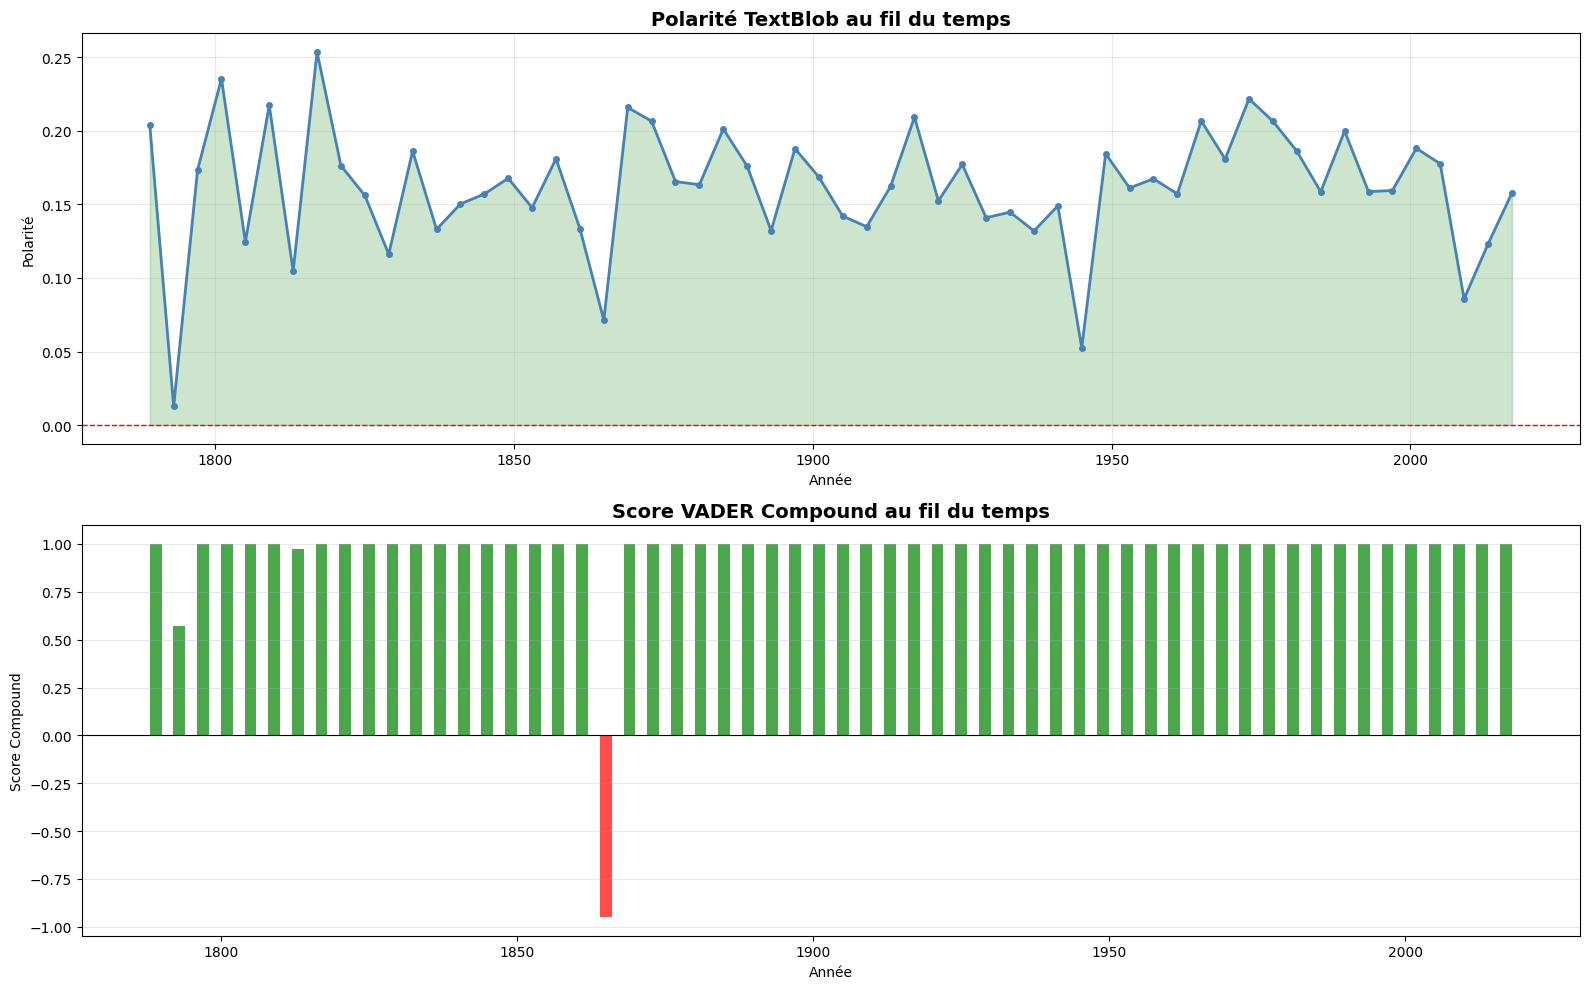

 Sauvegardé : ../output/01_sentiment_over_time.png


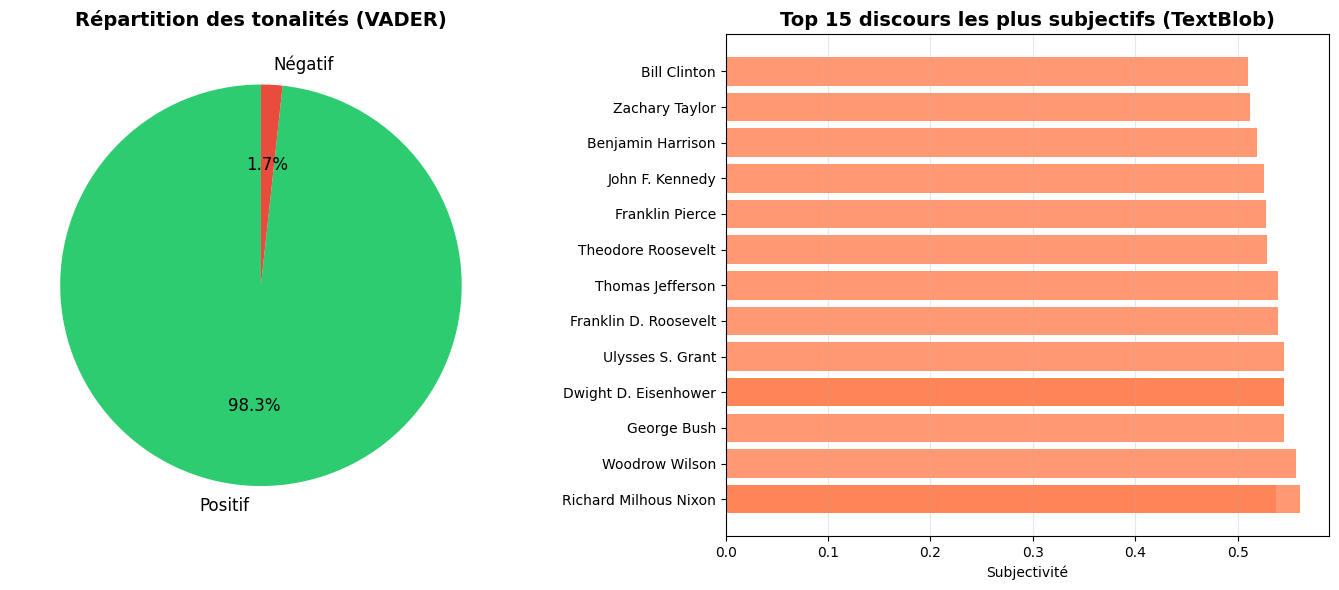

 Sauvegardé : ../output/02_tone_distribution.png


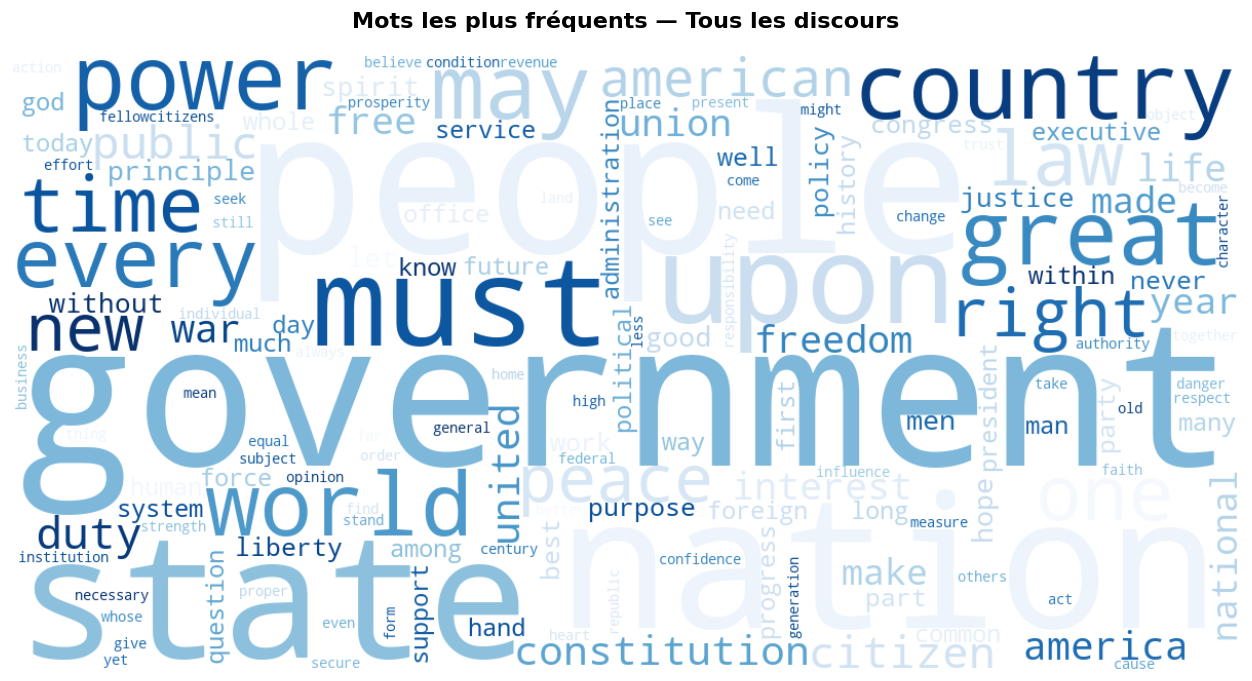

 Sauvegardé : ../output/03_wordcloud_global.png


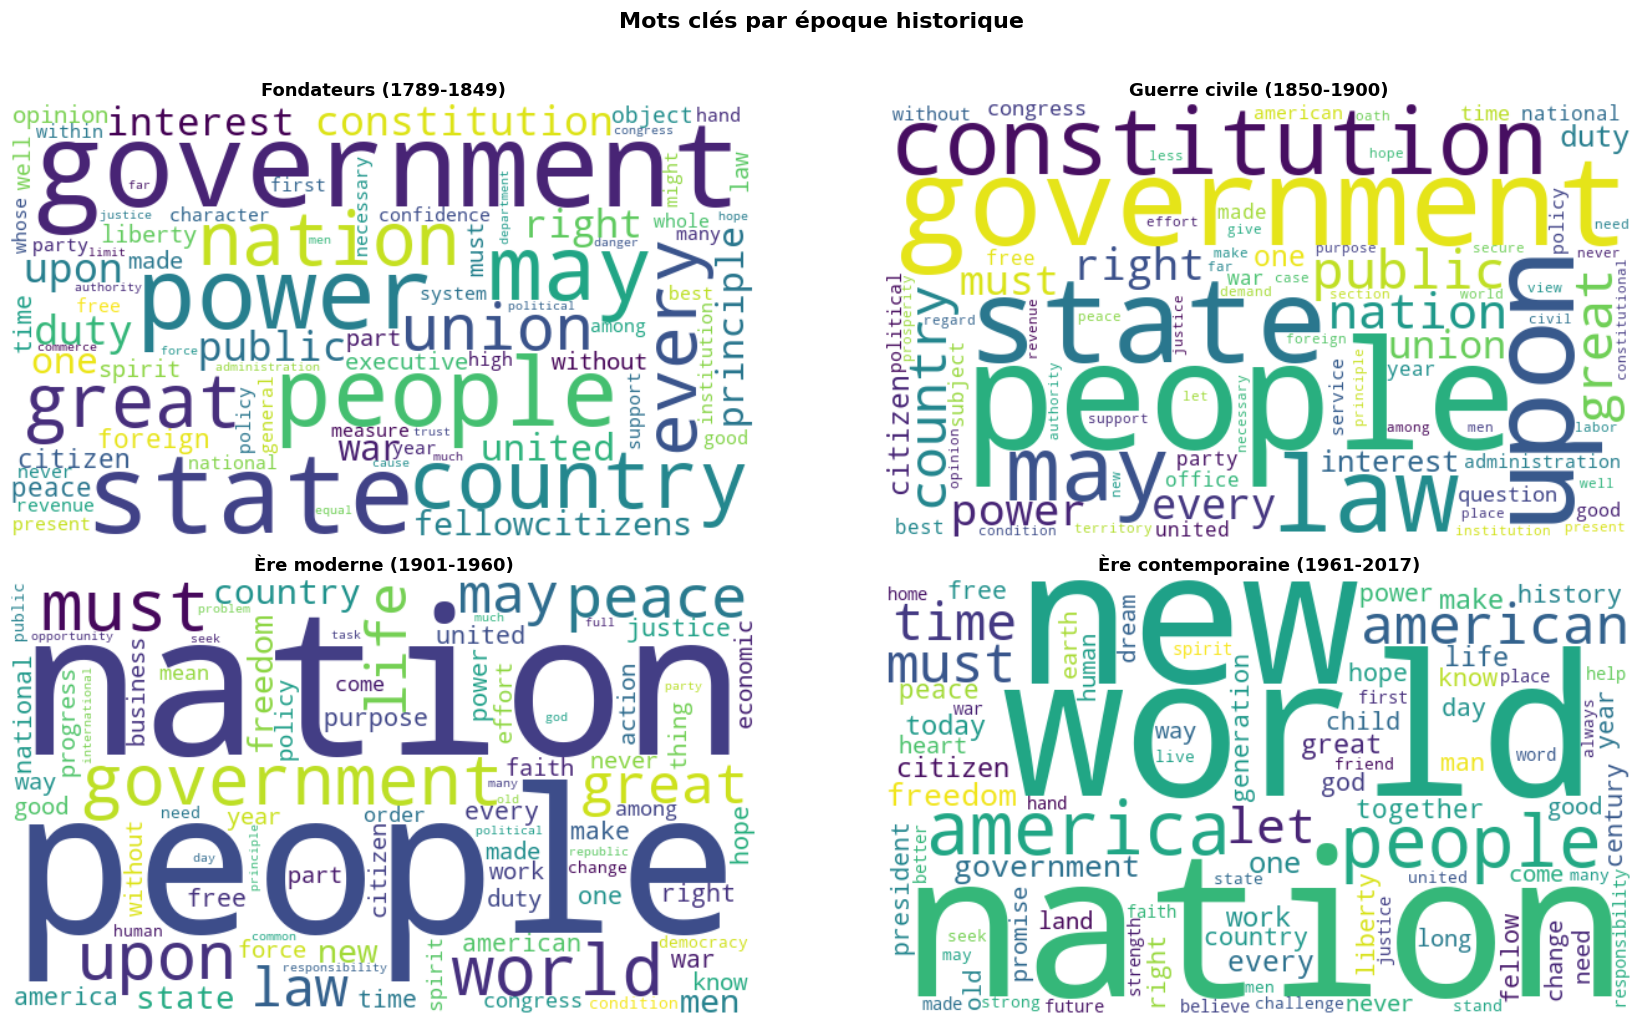

 Sauvegardé : ../output/04_wordcloud_by_era.png


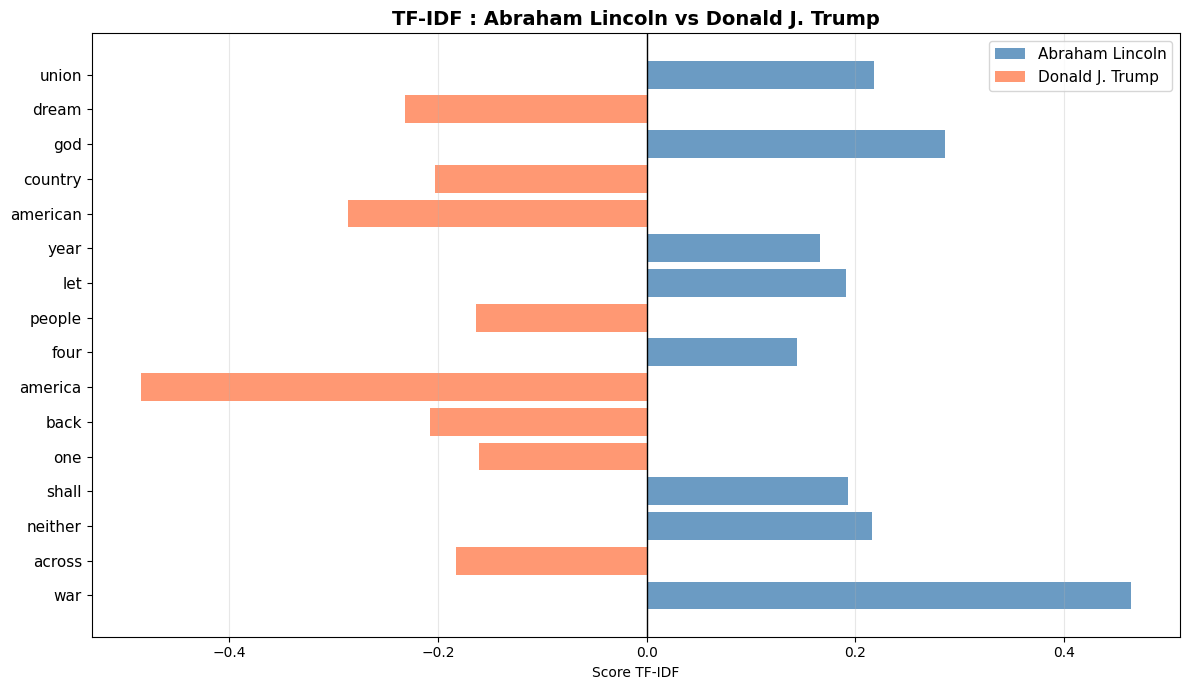

 Sauvegardé : ../output/05_tfidf_comparison.png


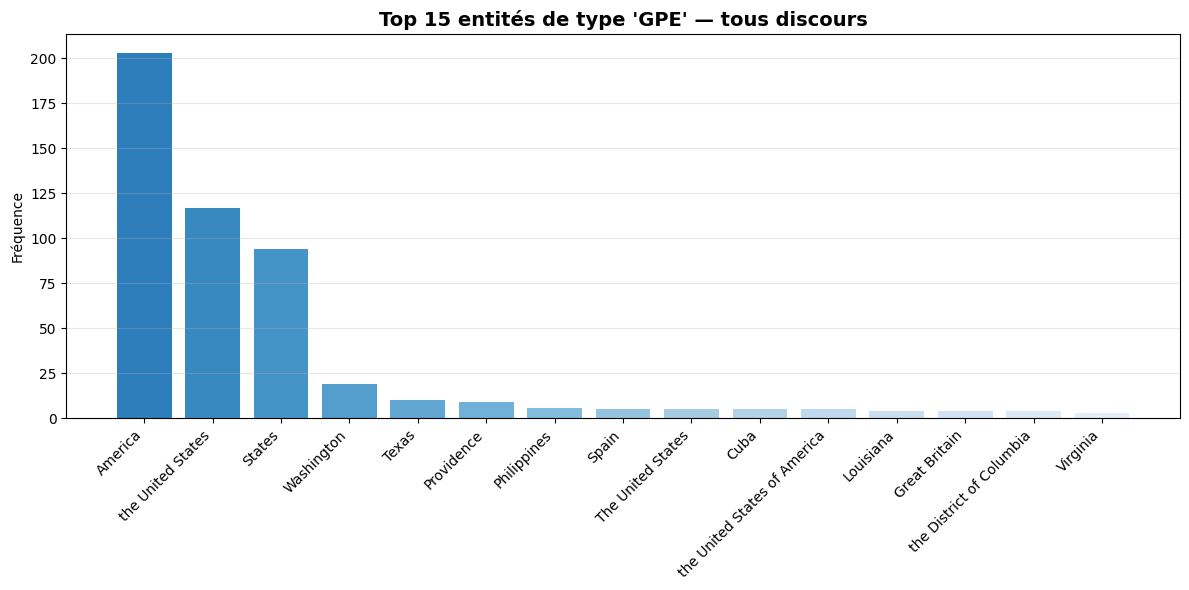

 Sauvegardé : ../output/06_top_entities.png


In [19]:
# ============================================================
# ÉTAPE 5 : Visualisations
# ============================================================

import importlib
import viz
importlib.reload(viz)
from viz import (plot_sentiment_over_time, plot_tone_distribution,
                 plot_wordcloud_global, plot_wordcloud_by_era,
                 plot_tfidf_comparison, plot_top_entities)

# 1. Sentiment dans le temps
plot_sentiment_over_time(df)

# 2. Distribution tonalités
plot_tone_distribution(df)

# 3. Wordcloud global
plot_wordcloud_global(df)

# 4. Wordclouds par époque
plot_wordcloud_by_era(df)

# 5. TF-IDF comparaison (Lincoln vs Trump — exemple parlant)
plot_tfidf_comparison(df_tfidf, "Abraham Lincoln", "Donald J. Trump")

# 6. Entités géographiques les plus citées
plot_top_entities(df, entity_type="GPE", top_n=15)

##  Analyse — Visualisations

### Sentiment dans le temps
La polarité TextBlob reste positive sur toute la période. Le score VADER
révèle Lincoln 1865 comme unique exception négative (-0.95).

### Répartition des tonalités
98.3% des discours sont positifs — cohérent avec la rhétorique d'investiture.
Richard Milhous Nixon et Woodrow Wilson sont les présidents les plus subjectifs.

### Wordclouds par époque
Shift sémantique clair entre les époques :
- **Fondateurs** → `state`, `constitution`, `government`
- **Guerre civile** → `war`, `law`, `union`
- **Ère moderne** → `world`, `peace`, `democracy`
- **Contemporain** → `america`, `freedom`, `new`

### TF-IDF Lincoln vs Trump
Deux univers rhétoriques opposés : gravité/religion/union pour Lincoln,
nationalisme/slogan/identité pour Trump.

### Entités géographiques (NER)
`America` (203x) domine largement, confirmant l'omniprésence de
l'identité nationale dans tous les discours.

In [20]:
# ============================================================
# ÉTAPE 6 : Interprétation et Recommandations
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║         SYNTHÈSE — DISCOURS D'INVESTITURE AMÉRICAINS         ║
╚══════════════════════════════════════════════════════════════╝

1. SENTIMENT GÉNÉRAL
─────────────────────
- 98.3% des discours ont une tonalité POSITIVE (VADER).
- La polarité TextBlob oscille entre 0.05 et 0.25 — tous restent
  dans une rhétorique d'espoir et d'unité nationale.
- Seul Lincoln (1865) affiche un score négatif (-0.95) :
  contexte de fin de guerre civile, discours de réconciliation
  mais chargé de gravité.

2. ÉVOLUTION HISTORIQUE (TF-IDF + Wordclouds)
──────────────────────────────────────────────
- 1789-1849 (Fondateurs) : vocabulaire centré sur
  "government", "state", "constitution" → construction
  des institutions.
- 1850-1900 (Guerre civile) : "war", "law", "union"
  dominent → conflits internes et reconstruction.
- 1901-1960 (Ère moderne) : "world", "peace", "nation"
  → montée en puissance internationale des États-Unis.
- 1961-2017 (Contemporain) : "america", "freedom",
  "new", "world" → projection mondiale et idéaux
  démocratiques.

3. THÈMES RÉCURRENTS (Wordcloud global)
────────────────────────────────────────
- "Government", "people", "nation" sont les 3 mots
  les plus utilisés sur 228 ans de discours.
- "Freedom" et "constitution" apparaissent dans toutes
  les époques → valeurs fondatrices constantes.

4. ENTITÉS GÉOGRAPHIQUES (NER)
───────────────────────────────
- "America" (203x) > "the United States" (118x) >
  "States" (94x) → identité nationale omniprésente.
- Présence de Spain, Philippines, Cuba → reflet des
  guerres coloniales (fin XIXe, début XXe).

5. INSIGHTS & RECOMMANDATIONS
──────────────────────────────
- Les discours d'investiture suivent un "template"
  rhétorique stable : ton positif, appel à l'unité,
  référence aux valeurs fondatrices.
- Le vocabulaire évolue avec les crises mondiales :
  "war" pic en 1813/1865/1917, "world" explose après 1945.
- Trump (2017) se distingue par "back", "dream",
  "america" → slogan MAGA très présent dans le TF-IDF,
  rupture rhétorique par rapport aux prédécesseurs.
- Lincoln 1865 reste le discours le plus atypique
  sentimentalement, le plus court, et le plus dense
  en références religieuses ("god").
""")


╔══════════════════════════════════════════════════════════════╗
║         SYNTHÈSE — DISCOURS D'INVESTITURE AMÉRICAINS         ║
╚══════════════════════════════════════════════════════════════╝

1. SENTIMENT GÉNÉRAL
─────────────────────
- 98.3% des discours ont une tonalité POSITIVE (VADER).
- La polarité TextBlob oscille entre 0.05 et 0.25 — tous restent
  dans une rhétorique d'espoir et d'unité nationale.
- Seul Lincoln (1865) affiche un score négatif (-0.95) :
  contexte de fin de guerre civile, discours de réconciliation
  mais chargé de gravité.

2. ÉVOLUTION HISTORIQUE (TF-IDF + Wordclouds)
──────────────────────────────────────────────
- 1789-1849 (Fondateurs) : vocabulaire centré sur
  "government", "state", "constitution" → construction
  des institutions.
- 1850-1900 (Guerre civile) : "war", "law", "union"
  dominent → conflits internes et reconstruction.
- 1901-1960 (Ère moderne) : "world", "peace", "nation"
  → montée en puissance internationale des États-Unis.
- 1961-20